# Predicción de Demanda Turística — Ushuaia

**Autor:** Darío Martínez  
**Materia:** Aprendizaje Automático — 3.º Cuatrimestre  
**Universidad:** Centro Politécnico Superior Malvinas Argentinas  
**Año:** 2026

---

## Objetivo

Predecir la **demanda turística mensual** de Ushuaia mediante **Regresión Lineal Múltiple**, sobre tres variables objetivo:

| Variable objetivo | Descripción |
|---|---|
| `ush_viaj_total` | Viajeros totales mensuales |
| `ush_pernoc_total` | Pernoctaciones totales mensuales |
| `parque_visitas_total` | Visitas mensuales al Parque Nacional Tierra del Fuego |

Anticipar esta demanda permite mejorar la planificación de servicios, hotelería, transporte e infraestructura en una región con una marcada estacionalidad turística.

---

## Índice del análisis

1. Configuración y carga de datos  
2. Preprocesamiento  
3. Análisis Exploratorio (EDA): evolución, estacionalidad, outliers y correlación  
4. Selección de variables (Correlación + VIF)  
5. Entrenamiento del modelo  
6. Evaluación: real vs predicho y **diagnóstico de regresión**  
7. Importancia de variables y análisis de residuos  
8. Métricas y proyección 2026  
9. Conclusiones


## 1. Configuración

Se importan las librerías y se define una **paleta de color corporativa unificada** (escala de azules) que se reutiliza en todos los gráficos para dar coherencia visual a la notebook.


In [1]:
# ── Celda 1: Importación de librerías y estilo visual ──────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── PALETA CORPORATIVA UNIFICADA (escala de azules) ────────────────
AZUL_OSCURO  = '#1F4E79'   # títulos / elementos fuertes
AZUL         = '#2E75B6'   # color primario de las series
AZUL_MEDIO   = '#5B9BD5'   # secundario
AZUL_CLARO   = '#9DC3E6'   # terciario / rellenos
GRIS         = '#7F7F7F'   # neutro (coef. negativos, referencias)
ROJO_ALERTA  = '#C00000'   # solo para marcar COVID / valores negativos

# Un color por cada variable objetivo, todos dentro de la gama azul
COLOR_TARGET = {
    'Viajeros totales':        AZUL,
    'Pernoctaciones totales':  AZUL_OSCURO,
    'Visitas Parque Nacional': AZUL_MEDIO,
}

# Estilo general de los gráficos
plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlecolor': AZUL_OSCURO,
    'axes.titleweight': 'bold',
    'font.size': 10,
})

print('Librerías importadas y paleta corporativa definida ✓')

Librerías importadas y paleta corporativa definida ✓


## 2. Carga del dataset

Serie temporal **mensual** construida a partir de fuentos como: el **INDEC** (Encuesta de Ocupación Hotelera) y **Open-Meteo** (variables climáticas). Cubre el período **2004–2025**.


In [2]:
# ── Celda 2: Carga del dataset ──────────────────────────────────────

df = pd.read_excel(
    r'C:\Users\dario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\03 - Instancia Parcial\ParciaML_DarioMartinez2026\data\processed\dataset_turismo_clima.xlsx',
    parse_dates=['fecha']
)

print(f'Dimensiones : {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Período     : {df["fecha"].min().strftime("%b %Y")} → {df["fecha"].max().strftime("%b %Y")}')
print(f'\nNulos en variables principales:')
print(df[['ush_viaj_total','ush_pernoc_total','parque_visitas_total','ush_toh %','ush_top %','ush_hab_disponibles','ush_plazas_disponibles']].isnull().sum())

Dimensiones : 263 filas × 83 columnas
Período     : Jan 2004 → Nov 2025

Nulos en variables principales:
ush_viaj_total              0
ush_pernoc_total            0
parque_visitas_total      132
ush_toh %                   3
ush_top %                   4
ush_hab_disponibles         3
ush_plazas_disponibles      3
dtype: int64


## 3. Preprocesamiento

Se aplican tres pasos antes de modelar:

1. **Imputación por mediana mensual** — los nulos en variables hoteleras se reemplazan con la mediana histórica del **mismo mes**, preservando la estacionalidad.
2. **Exclusión del período COVID** (mar 2020 – jun 2021) — un evento atípico que distorsionaría el aprendizaje del modelo.
3. **División temporal** — el modelo aprende con datos **hasta 2022** y se evalúa con **2023 en adelante**, respetando el orden cronológico para evitar *data leakage* temporal.


In [3]:
# ── Celda 3: Preprocesamiento ───────────────────────────────────────

# 1. Imputar nulos en variables hoteleras con la mediana del mismo mes
cols_hotel = ['ush_toh %', 'ush_top %',
              'ush_hab_disponibles', 'ush_plazas_disponibles']

for col in cols_hotel:
    df[col] = df.groupby('mes.1')[col].transform(
        lambda x: x.fillna(x.median()))

# 2. Excluir período COVID (marzo 2020 - junio 2021)
mask_covid = (df['fecha'] >= '2020-03-01') & (df['fecha'] <= '2021-06-01')
df_modelo  = df[~mask_covid].copy()

# 3. Split temporal: train hasta 2022 / test desde 2023
df_train = df_modelo[df_modelo['anio'] <= 2022]
df_test  = df_modelo[df_modelo['anio'] >= 2023]

print(f'Registros totales sin COVID : {len(df_modelo)}')
print(f'Train (hasta dic 2022)      : {len(df_train)} meses')
print(f'Test  (desde ene 2023)      : {len(df_test)} meses')

Registros totales sin COVID : 247
Train (hasta dic 2022)      : 212 meses
Test  (desde ene 2023)      : 35 meses


## 4. Análisis Exploratorio (EDA)

### 4.1 Evolución histórica

Las tres series se grafican en la escala de azul corporativa. La franja roja marca el período COVID excluido del modelado.


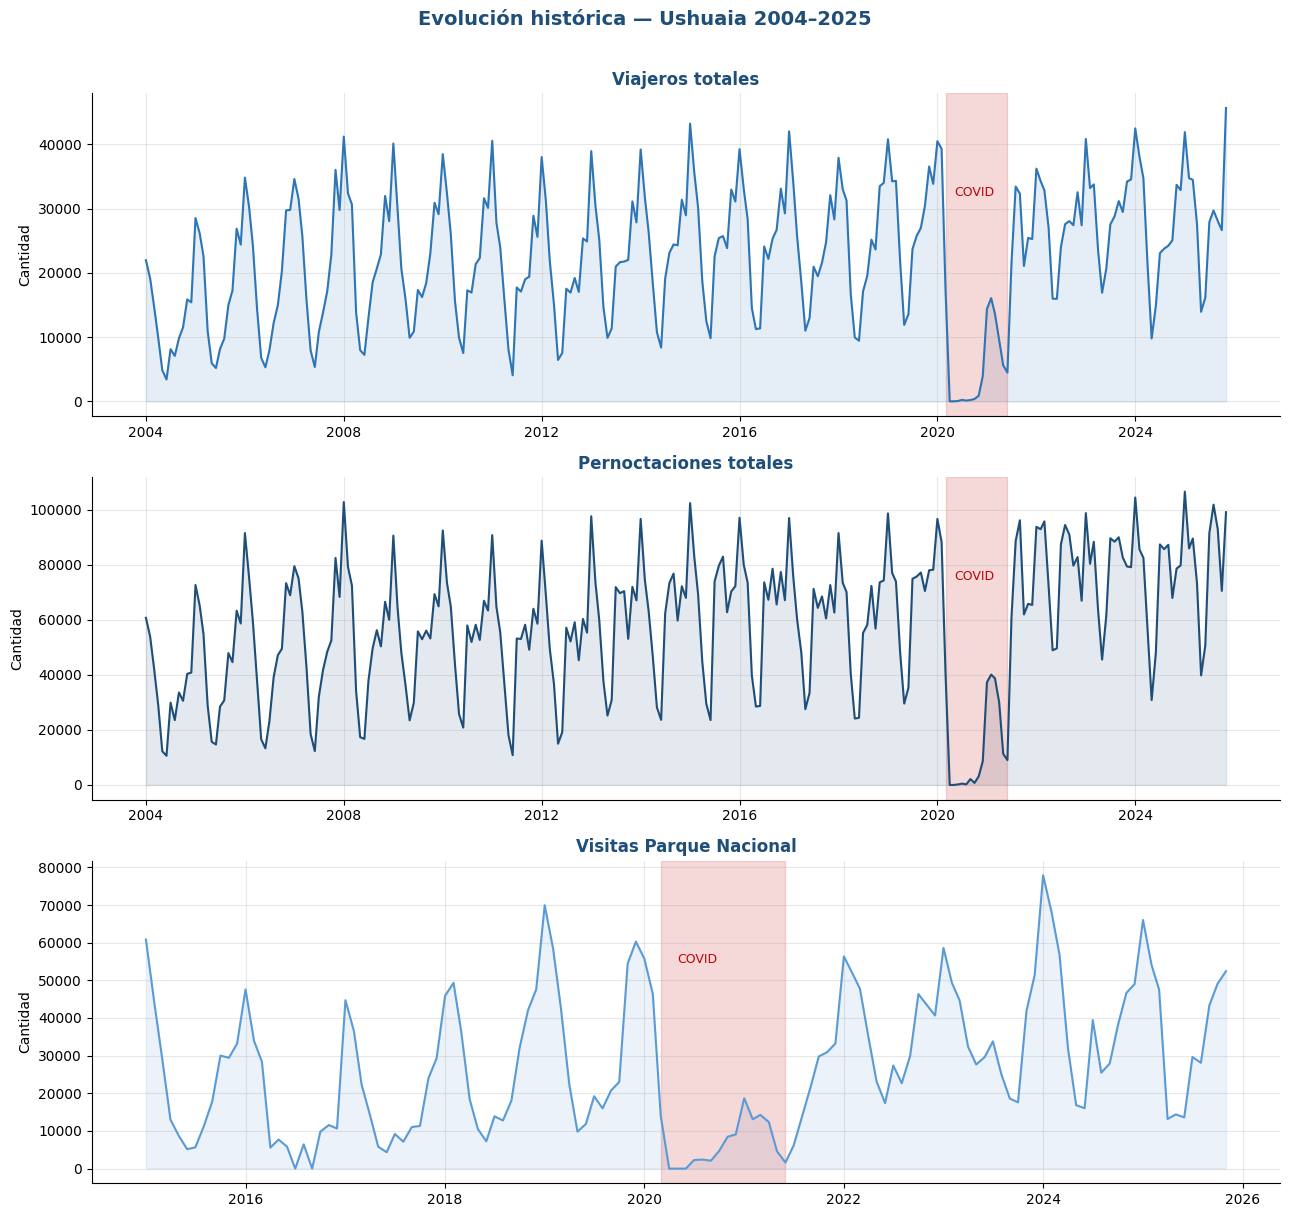

In [4]:
# ── Celda 4: EDA - Evolución histórica ─────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

config = [
    ('ush_viaj_total',       'Viajeros totales',        AZUL),
    ('ush_pernoc_total',     'Pernoctaciones totales',   AZUL_OSCURO),
    ('parque_visitas_total', 'Visitas Parque Nacional',  AZUL_MEDIO),
]

for ax, (col, titulo, color) in zip(axes, config):
    ax.plot(df['fecha'], df[col], color=color, linewidth=1.5)
    ax.fill_between(df['fecha'], df[col], alpha=0.12, color=color)

    # Sombrear COVID
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
               alpha=0.15, color=ROJO_ALERTA)
    ax.text(pd.Timestamp('2020-05-01'),
            df[col].max() * 0.7, 'COVID', color=ROJO_ALERTA, fontsize=9)

    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel('Cantidad')

plt.suptitle('Evolución histórica — Ushuaia 2004–2025',
             fontsize=14, y=1.01, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones del EDA histórico**

- Las tres series muestran **tendencia creciente** desde 2004 con estacionalidad marcada.
- El impacto del COVID (franja roja) es visible como una caída abrupta en 2020–2021.
- **Post-COVID, el turismo superó los niveles previos a 2020**, alcanzando récords históricos en 2023–2024.
- Las visitas al Parque Nacional comienzan en 2015, con menor cantidad de registros disponibles.


### 4.2 Estacionalidad mensual

Promedio histórico de cada mes (sin COVID), para identificar las temporadas altas y bajas.


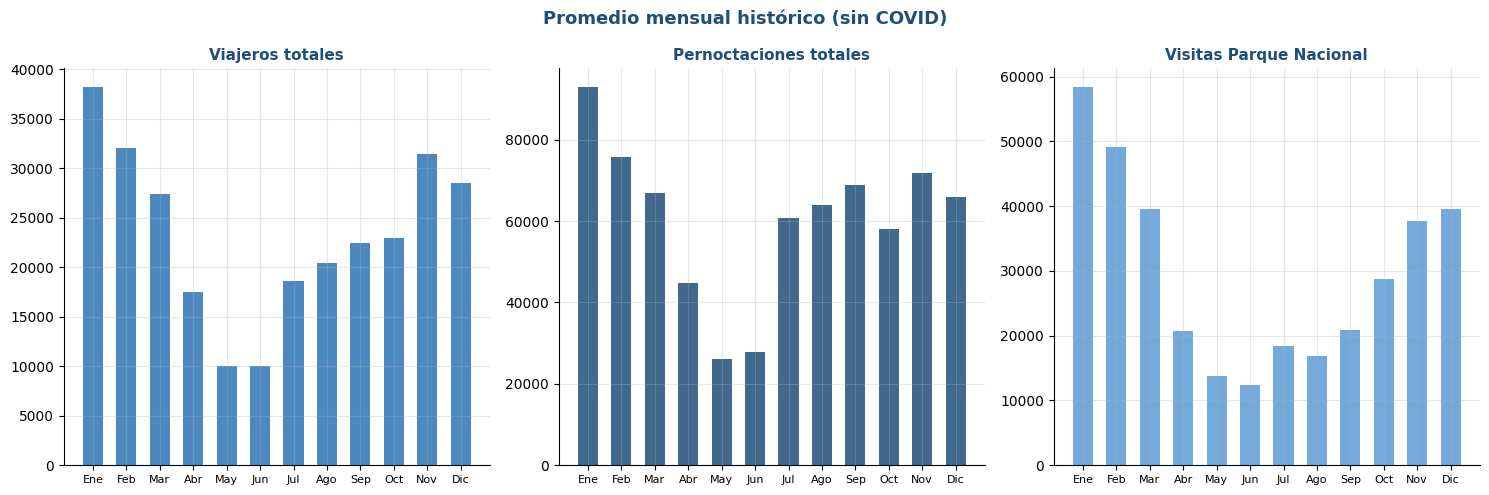

In [5]:
# ── Celda 5: EDA - Estacionalidad mensual ──────────────────────────

meses_str = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

config = [
    ('ush_viaj_total',       'Viajeros totales',       AZUL),
    ('ush_pernoc_total',     'Pernoctaciones totales',  AZUL_OSCURO),
    ('parque_visitas_total', 'Visitas Parque Nacional', AZUL_MEDIO),
]

for ax, (col, titulo, color) in zip(axes, config):
    por_mes = df_modelo.groupby('mes.1')[col].mean()
    ax.bar(por_mes.index, por_mes.values, color=color, alpha=0.85, width=0.6)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_str, fontsize=8)
    ax.set_title(titulo, fontsize=11)

plt.suptitle('Promedio mensual histórico (sin COVID)',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

**Patrones estacionales identificados**

- **Viajeros y pernoctaciones:** dos temporadas altas claramente definidas — **verano (enero–febrero)** para turismo internacional e **invierno (julio–agosto)** para turismo de nieve (Cerro Castor). El valle más profundo ocurre en mayo–junio.
- **Parque Nacional:** patrón diferente al turismo general. Las visitas se concentran en **verano (enero–febrero)**, ya que es un atractivo natural de clima cálido. Esto justifica que el mes sea una *feature* relevante del modelo.


### 4.3 Análisis de outliers (método IQR)

Se aplica la **regla del rango intercuartílico (IQR)**: se consideran candidatos a outlier los valores fuera del intervalo $[Q_1 - 1{,}5 \cdot RIC;\ Q_3 + 1{,}5 \cdot RIC]$.


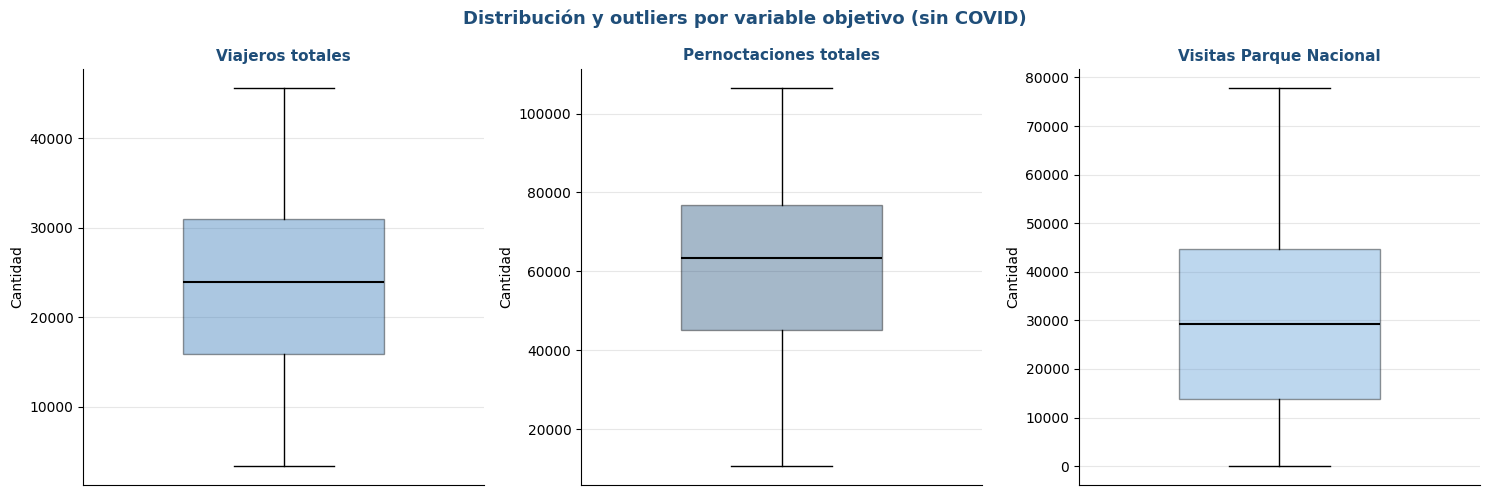

DETECCIÓN DE OUTLIERS — Regla IQR (1.5 × RIC)

Viajeros totales
  Q1=15,910  |  Q3=30,999  |  RIC=15,088
  Límites: [-6,722 ; 53,632]
  Outliers: 0 de 247 registros (0.0%)

Pernoctaciones totales
  Q1=45,033  |  Q3=76,898  |  RIC=31,864
  Límites: [-2,764 ; 124,694]
  Outliers: 0 de 247 registros (0.0%)

Visitas Parque Nacional
  Q1=13,868  |  Q3=44,697  |  RIC=30,829
  Límites: [-32,376 ; 90,940]
  Outliers: 0 de 115 registros (0.0%)

CONCLUSIÓN: los valores extremos corresponden a picos de temporada
alta (verano/invierno), no a errores de medición. Se conservan.


In [6]:
# ── Celda 5b: EDA - Análisis de outliers (método IQR) ──────────────

meses_str = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']

config = [
    ('ush_viaj_total',       'Viajeros totales',        AZUL),
    ('ush_pernoc_total',     'Pernoctaciones totales',   AZUL_OSCURO),
    ('parque_visitas_total', 'Visitas Parque Nacional',  AZUL_MEDIO),
]

# ── 1. Boxplots: distribución global de cada variable objetivo ──────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, titulo, color) in zip(axes, config):
    datos = df_modelo[col].dropna()
    bp = ax.boxplot(datos, patch_artist=True, widths=0.5,
                    flierprops=dict(marker='o', markersize=5,
                                    markerfacecolor=color, alpha=0.6))
    bp['boxes'][0].set(facecolor=color, alpha=0.4)
    bp['medians'][0].set(color='black', linewidth=1.5)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Cantidad')
    ax.set_xticks([])

plt.suptitle('Distribución y outliers por variable objetivo (sin COVID)',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Detección cuantitativa por regla IQR (1.5 × RIC) ─────────────
print('DETECCIÓN DE OUTLIERS — Regla IQR (1.5 × RIC)')
print('=' * 60)

resumen = []
for col, titulo, _ in config:
    datos = df_modelo[col].dropna()
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    ric = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * ric, q3 + 1.5 * ric

    out_mask = (datos < lim_inf) | (datos > lim_sup)
    n_out = int(out_mask.sum())
    pct = 100 * n_out / len(datos)

    print(f'\n{titulo}')
    print(f'  Q1={q1:,.0f}  |  Q3={q3:,.0f}  |  RIC={ric:,.0f}')
    print(f'  Límites: [{lim_inf:,.0f} ; {lim_sup:,.0f}]')
    print(f'  Outliers: {n_out} de {len(datos)} registros ({pct:.1f}%)')

    if n_out > 0:
        meses_out = df_modelo.loc[datos.index[out_mask], ['anio', 'mes.1']]
        etiquetas = [f'{meses_str[int(m)-1]} {int(a)}'
                     for a, m in zip(meses_out['anio'], meses_out['mes.1'])]
        print(f'  Períodos : {", ".join(etiquetas)}')

    resumen.append((titulo, n_out, pct))

print('\n' + '=' * 60)
print('CONCLUSIÓN: los valores extremos corresponden a picos de temporada')
print('alta (verano/invierno), no a errores de medición. Se conservan.')

**Hallazgos del análisis de outliers**

- Los valores extremos detectados **no son errores de medición**, sino picos legítimos de las temporadas altas (verano: ene–feb; invierno: jul–ago), coherentes con la fuerte estacionalidad del turismo en Ushuaia.
- Por tratarse de una **serie temporal**, eliminar estos meses destruiría la señal estacional que el modelo debe aprender. Por lo tanto **se conservan todos los registros**.
- La presencia de estos picos anticipa la **heterocedasticidad leve** que se observará más adelante en el análisis de residuos (el error crece en los meses de mayor demanda).


### 4.4 Matriz de correlación

Relación lineal entre todas las *features* candidatas y las tres variables objetivo. 


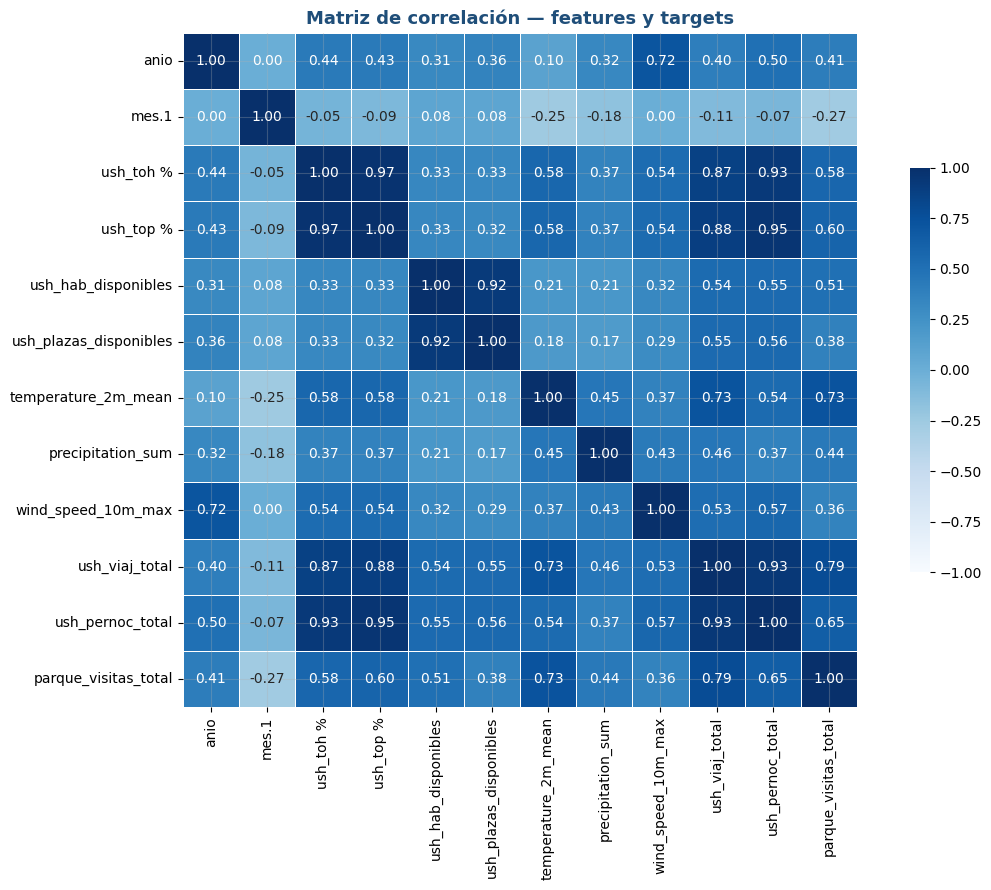

In [7]:
# ── Celda 6: EDA - Matriz de correlación ───────────────────────────

FEATURES = ['anio', 'mes.1', 'ush_toh %', 'ush_top %',
            'ush_hab_disponibles', 'ush_plazas_disponibles',
            'temperature_2m_mean', 'precipitation_sum',
            'wind_speed_10m_max']

TARGETS = ['ush_viaj_total', 'ush_pernoc_total', 'parque_visitas_total']

cols_corr = FEATURES + TARGETS
corr = df_modelo[cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.6})
ax.set_title('Matriz de correlación — features y targets',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

### Selección inicial de variables candidatas

Antes de la selección estadística (Correlación + VIF) se realiza una **selección por conocimiento del dominio**, descartando:

- **Desagregaciones del propio target** (pernoctaciones/viajeros por residencia, país y provincia; visitas al parque por tipo): usarlas constituiría **fuga de información** (*data leakage*), ya que suman exactamente el total a predecir.
- **Variables de ocupación absoluta** (`ush_hab_ocupadas`, `ush_plazas_ocupadas`) y de **cruceros**: redundantes con el target o con cobertura temporal insuficiente.

Se retienen **9 predictores genuinos**, agrupados en tres familias:

| Grupo | Variables |
|-------|-----------|
| Temporales | `anio`, `mes.1` |
| Oferta y ocupación hotelera | `ush_toh %`, `ush_top %`, `ush_hab_disponibles`, `ush_plazas_disponibles` |
| Clima | `temperature_2m_mean`, `precipitation_sum`, `wind_speed_10m_max` |


## 5. Selección de variables (Correlación + VIF)

Sobre las 9 candidatas se aplica una selección **en dos pasos, por cada target**:

- **Paso 1 — Correlación:** se descartan las variables con correlación absoluta con el target inferior a 0,10.
- **Paso 2 — VIF iterativo:** se elimina la multicolinealidad calculando el *Factor de Inflación de la Varianza* sobre variables **estandarizadas**, removiendo de a una las que superan el umbral (VIF > 10).

Por este motivo, **cada modelo conserva su propio conjunto de variables**.


In [8]:
# ── Celda 6b: Selección de features por Correlación + VIF ──────────

from statsmodels.stats.outliers_influence import variance_inflation_factor

FEATURES_CANDIDATAS = ['anio', 'mes.1', 'ush_toh %', 'ush_top %',
                       'ush_hab_disponibles', 'ush_plazas_disponibles',
                       'temperature_2m_mean', 'precipitation_sum',
                       'wind_speed_10m_max']

TARGETS = {
    'ush_viaj_total':       'Viajeros totales',
    'ush_pernoc_total':     'Pernoctaciones totales',
    'parque_visitas_total': 'Visitas Parque Nacional',
}

UMBRAL_CORR = 0.10   # correlación mínima con el target
UMBRAL_VIF  = 10.0   # VIF máximo aceptable


def vif_iterativo(df_t, feats, umbral):
    """Elimina de a UNA la variable con mayor VIF y recalcula,
    hasta que todas queden por debajo del umbral. El VIF se calcula
    sobre variables ESTANDARIZADAS para que las diferencias de escala
    no inflen el resultado artificialmente."""
    feats = list(feats)
    historial = []
    while len(feats) > 1:
        X = StandardScaler().fit_transform(df_t[feats].values.astype(float))
        vifs = [variance_inflation_factor(X, i) for i in range(len(feats))]
        vif_max = max(vifs)
        idx_max = int(np.argmax(vifs))
        if vif_max > umbral:
            historial.append((feats[idx_max], vif_max))
            feats.pop(idx_max)
        else:
            break
    X = StandardScaler().fit_transform(df_t[feats].values.astype(float))
    vif_final = pd.DataFrame({
        'variable': feats,
        'VIF': [variance_inflation_factor(X, i) for i in range(len(feats))]
    }).sort_values('VIF', ascending=False)
    return feats, vif_final, historial


features_seleccionadas = {}

for col_target, label in TARGETS.items():

    print("=" * 55)
    print(f"TARGET: {label}")
    print("=" * 55)

    df_t = df_modelo.dropna(subset=[col_target] + FEATURES_CANDIDATAS)

    # ── PASO 1: Correlación con el target ──────────────────────────
    corr_target = (df_t[FEATURES_CANDIDATAS]
                   .corrwith(df_t[col_target])
                   .abs()
                   .sort_values(ascending=False))

    eliminadas_corr = corr_target[corr_target < UMBRAL_CORR].index.tolist()
    features_paso1  = corr_target[corr_target >= UMBRAL_CORR].index.tolist()

    print(f"\nPASO 1 — Correlación con el target (umbral ≥ {UMBRAL_CORR})")
    print(corr_target.round(3).to_string())
    if eliminadas_corr:
        print(f"  ✗ Eliminadas por baja correlación: {eliminadas_corr}")
    print(f"  ✓ Pasan al paso 2: {features_paso1}")

    # ── PASO 2: VIF iterativo sobre variables estandarizadas ───────
    features_final, vif_final, historial = vif_iterativo(
        df_t, features_paso1, UMBRAL_VIF)

    print(f"\nPASO 2 — VIF iterativo sobre variables estandarizadas (umbral ≤ {UMBRAL_VIF})")
    if historial:
        for var, v in historial:
            print(f"  ✗ Eliminada por multicolinealidad: {var:25s} (VIF = {v:.1f})")
    else:
        print("  (ninguna variable supera el umbral)")
    print("\n  VIF final de las variables conservadas:")
    print(vif_final.to_string(index=False))
    print(f"\n  ✓ FEATURES FINALES: {features_final}")

    features_seleccionadas[col_target] = features_final
    print()

# ── Resumen comparativo ─────────────────────────────────────────────
print("=" * 55)
print("RESUMEN — FEATURES SELECCIONADAS POR TARGET")
print("=" * 55)
for col_target, label in TARGETS.items():
    print(f"\n{label}:")
    print(f"  {features_seleccionadas[col_target]}")

TARGET: Viajeros totales

PASO 1 — Correlación con el target (umbral ≥ 0.1)
ush_top %                 0.884
ush_toh %                 0.870
temperature_2m_mean       0.725
ush_plazas_disponibles    0.551
ush_hab_disponibles       0.544
wind_speed_10m_max        0.529
precipitation_sum         0.457
anio                      0.404
mes.1                     0.107
  ✓ Pasan al paso 2: ['ush_top %', 'ush_toh %', 'temperature_2m_mean', 'ush_plazas_disponibles', 'ush_hab_disponibles', 'wind_speed_10m_max', 'precipitation_sum', 'anio', 'mes.1']

PASO 2 — VIF iterativo sobre variables estandarizadas (umbral ≤ 10.0)
  ✗ Eliminada por multicolinealidad: ush_toh %                 (VIF = 18.6)

  VIF final de las variables conservadas:
              variable      VIF
ush_plazas_disponibles 7.087558
   ush_hab_disponibles 6.996009
    wind_speed_10m_max 2.807065
                  anio 2.628374
   temperature_2m_mean 2.024477
             ush_top % 1.992147
     precipitation_sum 1.449620
          

**Confirmación de la selección**

- `ush_toh %` y `ush_top %` muestran correlación > 0,87 con viajeros, pero entre sí correlacionan 0,97 → el **VIF elimina una de las dos** por multicolinealidad.
- `temperature_2m_mean` correlaciona 0,56 con viajeros y 0,59 con el Parque.
- `anio` captura la tendencia de crecimiento histórico; `mes.1`, la estacionalidad.


### 5.1 Relación de cada feature con su target

Para cada variable objetivo se grafican únicamente las *features* que superaron la selección Correlación + VIF, con su **recta de tendencia** (ajuste lineal univariado) y el coeficiente de correlación *r*. Esto verifica visualmente el supuesto de **relación aproximadamente lineal** antes de entrenar el modelo múltiple.


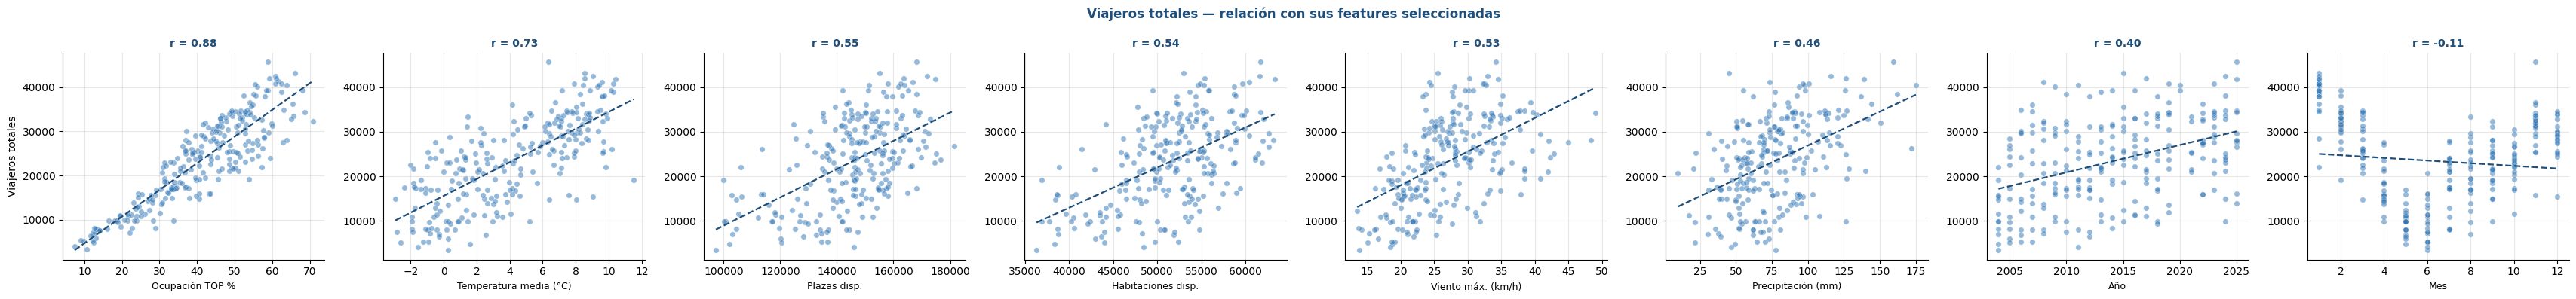

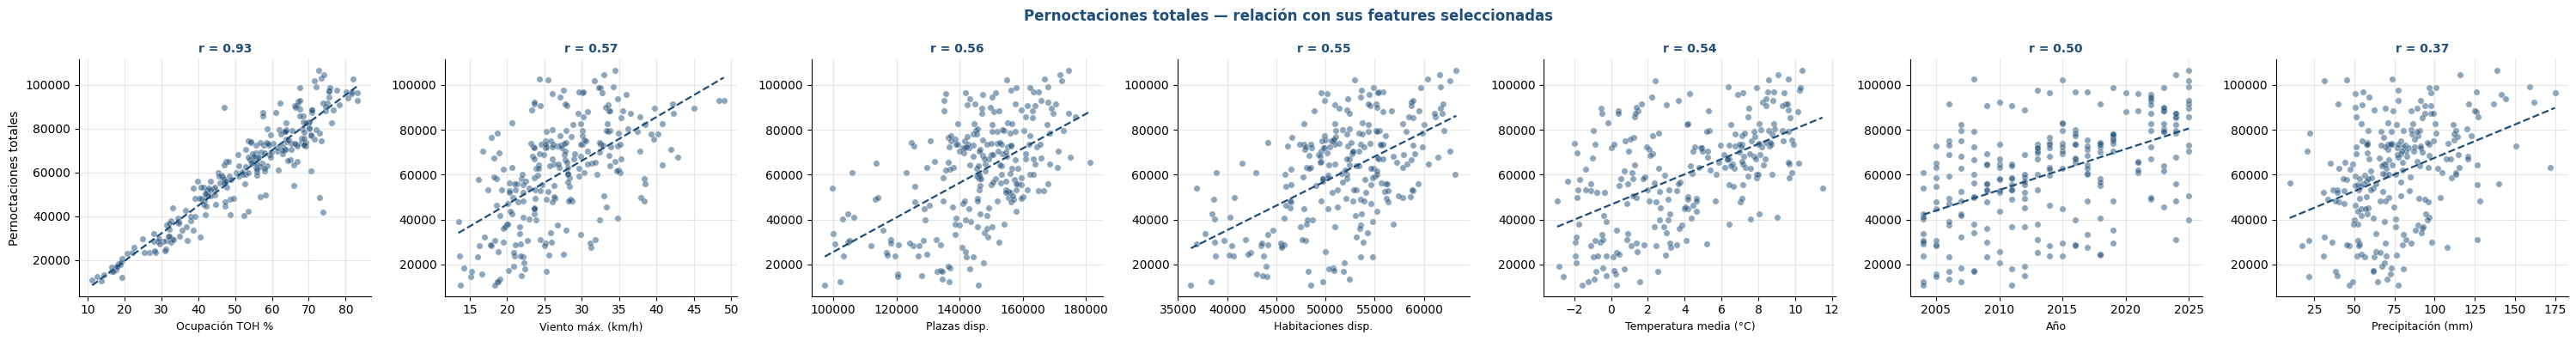

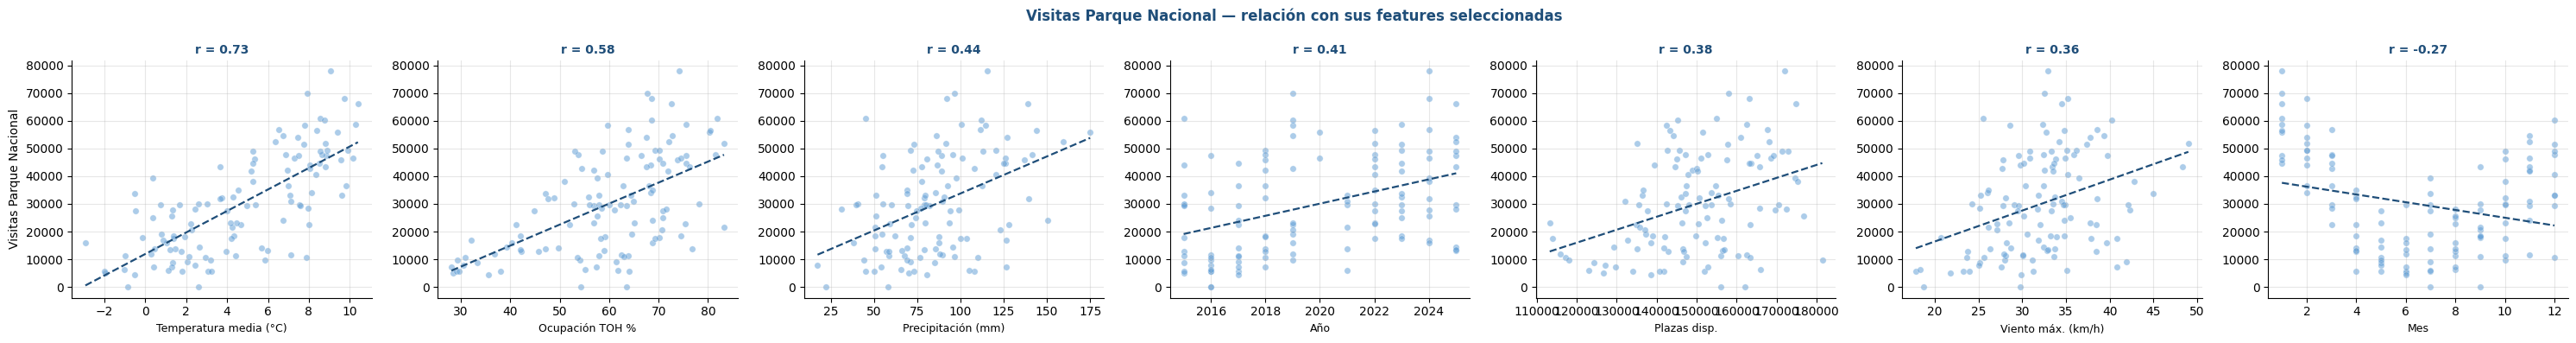

In [9]:
# ── Celda 6c: EDA - Relación de cada feature seleccionada vs target ──

nombres = {
    'anio': 'Año', 'mes.1': 'Mes',
    'ush_toh %': 'Ocupación TOH %', 'ush_top %': 'Ocupación TOP %',
    'ush_hab_disponibles': 'Habitaciones disp.',
    'ush_plazas_disponibles': 'Plazas disp.',
    'temperature_2m_mean': 'Temperatura media (°C)',
    'precipitation_sum': 'Precipitación (mm)',
    'wind_speed_10m_max': 'Viento máx. (km/h)',
}

for col_target, label in TARGETS.items():
    feats = features_seleccionadas[col_target]
    color = COLOR_TARGET[label]

    df_t = df_modelo.dropna(subset=[col_target] + feats)

    n = len(feats)
    fig, axes = plt.subplots(1, n, figsize=(4.3 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, feat in zip(axes, feats):
        x = df_t[feat].values
        y = df_t[col_target].values

        ax.scatter(x, y, color=color, alpha=0.5, s=28,
                   edgecolor='white', linewidth=0.4)

        # Recta de tendencia (ajuste lineal de 1 variable)
        coef = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(coef, xs), color=AZUL_OSCURO,
                linewidth=1.6, linestyle='--')

        r = np.corrcoef(x, y)[0, 1]
        ax.set_xlabel(nombres.get(feat, feat), fontsize=9)
        ax.set_title(f'r = {r:.2f}', fontsize=10)

    axes[0].set_ylabel(label, fontsize=10)
    fig.suptitle(f'{label} — relación con sus features seleccionadas',
                 fontsize=12, color=AZUL_OSCURO, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Entrenamiento del modelo

- **Algoritmo:** Regresión Lineal Múltiple, apropiado para relaciones continuas entre features numéricas y un target cuantitativo.
- **Un modelo por target**, cada uno con sus features propias (las que superaron Correlación + VIF).
- **Escalado** con `StandardScaler`, ajustado **solo en train** y aplicado a test, para evitar fuga de información.
- **Validación cruzada** (R² CV) con k=5 folds sobre el entrenamiento, para medir la capacidad de generalización.


In [10]:
# ── Celda 7: Definición y entrenamiento del modelo ──────────────────

TARGETS = {
    'ush_viaj_total':       'Viajeros totales',
    'ush_pernoc_total':     'Pernoctaciones totales',
    'parque_visitas_total': 'Visitas Parque Nacional',
}

resultados = {}

for col_target, label in TARGETS.items():

    FEATURES = features_seleccionadas[col_target]   # features propias del target

    df_t = df_modelo.dropna(subset=[col_target] + FEATURES)

    X_train = df_t[df_t['anio'] <= 2022][FEATURES].values
    X_test  = df_t[df_t['anio'] >= 2023][FEATURES].values
    y_train = df_t[df_t['anio'] <= 2022][col_target].values
    y_test  = df_t[df_t['anio'] >= 2023][col_target].values
    fechas  = df_t[df_t['anio'] >= 2023]['fecha'].values
    meses   = df_t[df_t['anio'] >= 2023]['mes.1'].values

    # Escalado: fit SOLO con train, transform a test
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    modelo = LinearRegression()
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    r2cv = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2').mean()

    resultados[label] = {
        'modelo': modelo, 'scaler': scaler, 'features': FEATURES,
        'fechas': fechas, 'meses': meses,
        'y_test': y_test, 'y_pred': y_pred,
        'MAE': mae, 'RMSE': rmse, 'R2': r2, 'R2CV': r2cv
    }

    print(f'── {label} ──')
    print(f'  Features  = {FEATURES}')
    print(f'  R²        = {r2:.3f}')
    print(f'  R² CV     = {r2cv:.3f}')
    print(f'  MAE       = {mae:,.0f}')
    print(f'  RMSE      = {rmse:,.0f}')
    print()

── Viajeros totales ──
  Features  = ['ush_top %', 'temperature_2m_mean', 'ush_plazas_disponibles', 'ush_hab_disponibles', 'wind_speed_10m_max', 'precipitation_sum', 'anio', 'mes.1']
  R²        = 0.828
  R² CV     = 0.874
  MAE       = 2,669
  RMSE      = 3,480

── Pernoctaciones totales ──
  Features  = ['ush_toh %', 'wind_speed_10m_max', 'ush_plazas_disponibles', 'ush_hab_disponibles', 'temperature_2m_mean', 'anio', 'precipitation_sum']
  R²        = 0.807
  R² CV     = 0.903
  MAE       = 5,337
  RMSE      = 8,114

── Visitas Parque Nacional ──
  Features  = ['temperature_2m_mean', 'ush_toh %', 'precipitation_sum', 'anio', 'ush_plazas_disponibles', 'wind_speed_10m_max', 'mes.1']
  R²        = 0.452
  R² CV     = 0.241
  MAE       = 10,239
  RMSE      = 12,308



## 7. Evaluación del modelo

### 7.1 Real vs Predicho en el tiempo

Comparación mes a mes entre el valor real (negro) y el predicho (azul) sobre el período de test 2023–2025.


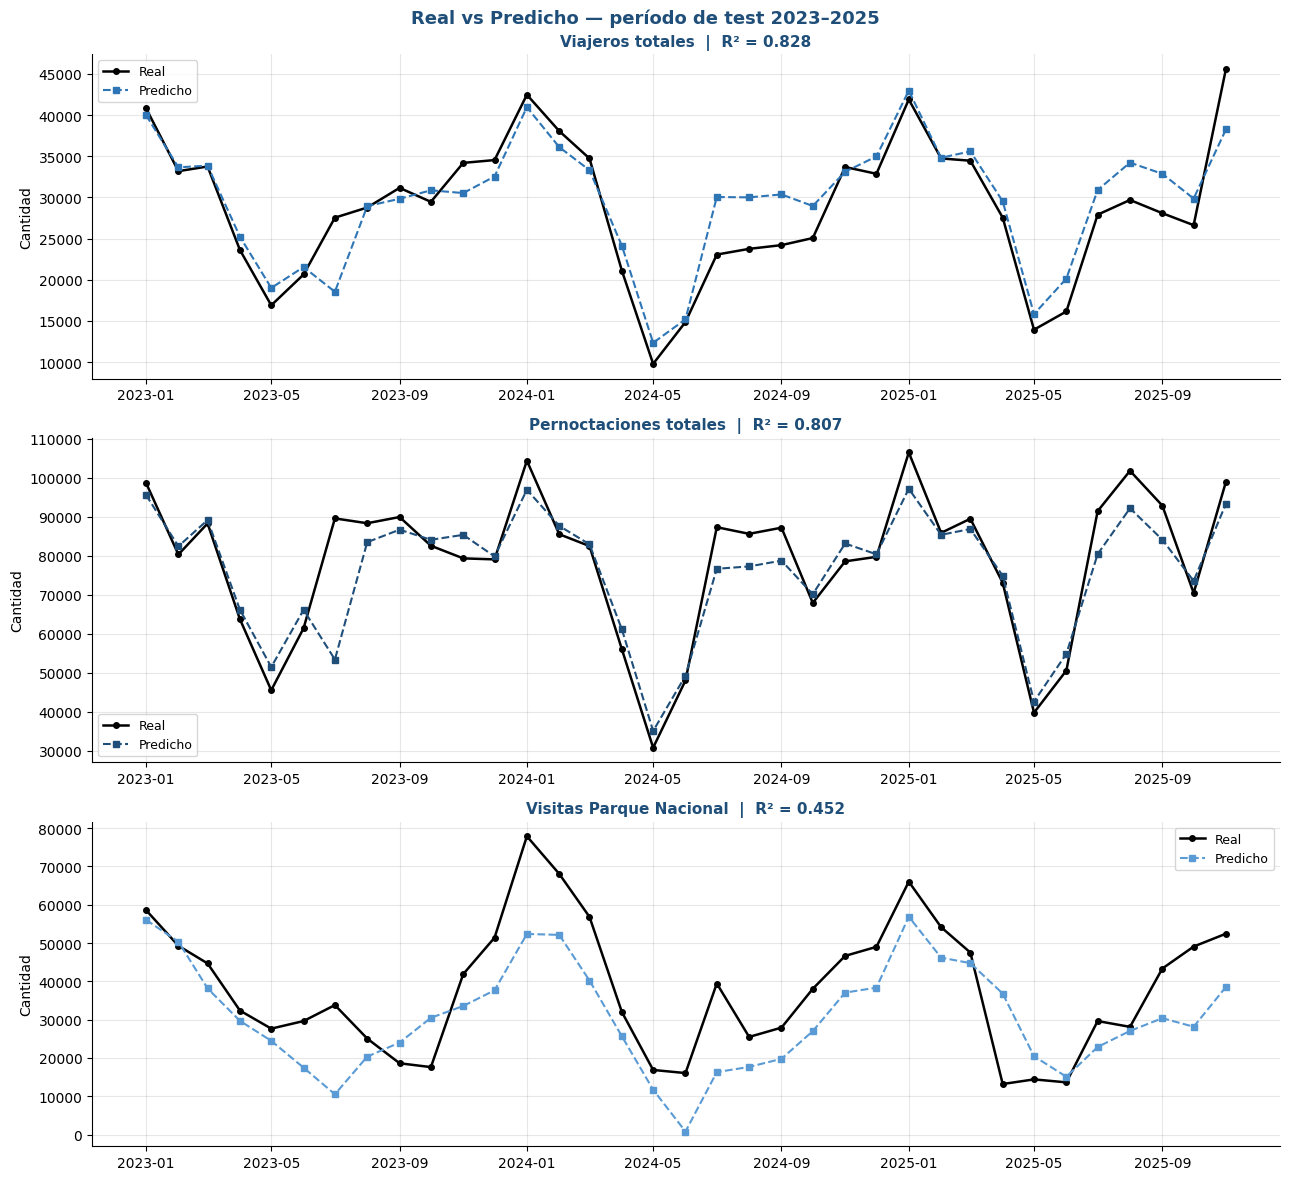

In [11]:
# ── Celda 8: Real vs Predicho (en el tiempo) ───────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

for ax, (label, color) in zip(axes, COLOR_TARGET.items()):
    res = resultados[label]
    ax.plot(res['fechas'], res['y_test'], 'o-', color='black',
            linewidth=1.8, markersize=4, label='Real')
    ax.plot(res['fechas'], res['y_pred'], 's--', color=color,
            linewidth=1.5, markersize=5, label='Predicho')
    ax.set_title(f"{label}  |  R² = {res['R2']:.3f}", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Cantidad')

plt.suptitle('Real vs Predicho — período de test 2023–2025',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación visual**

- **Viajeros (R² = 0,828):** el mejor ajuste de los tres modelos; las curvas real y predicha son muy similares.
- **Pernoctaciones (R² = 0,807):** buen ajuste general, sigue la tendencia con desvíos en algunos picos.
- **Parque Nacional (R² = 0,452):** mayor dispersión entre real y predicho, explicada por la menor cantidad de datos disponibles (desde 2015).

### 7.2 Diagnóstico de regresión

Dos gráficos clásicos del diagnóstico de un modelo de regresión lineal:

- **Predicho vs Real (dispersión):** cada punto es un mes. La línea diagonal punteada representa la predicción perfecta (predicho = real). Cuanto más cerca de la diagonal caen los puntos, mejor es el ajuste.
- **Residuos vs Predicho:** permite detectar **heterocedasticidad**. Si la nube de puntos se mantiene pareja alrededor de la línea cero, la varianza del error es constante; si se "abre" en abanico hacia la derecha, el error crece con la magnitud predicha.


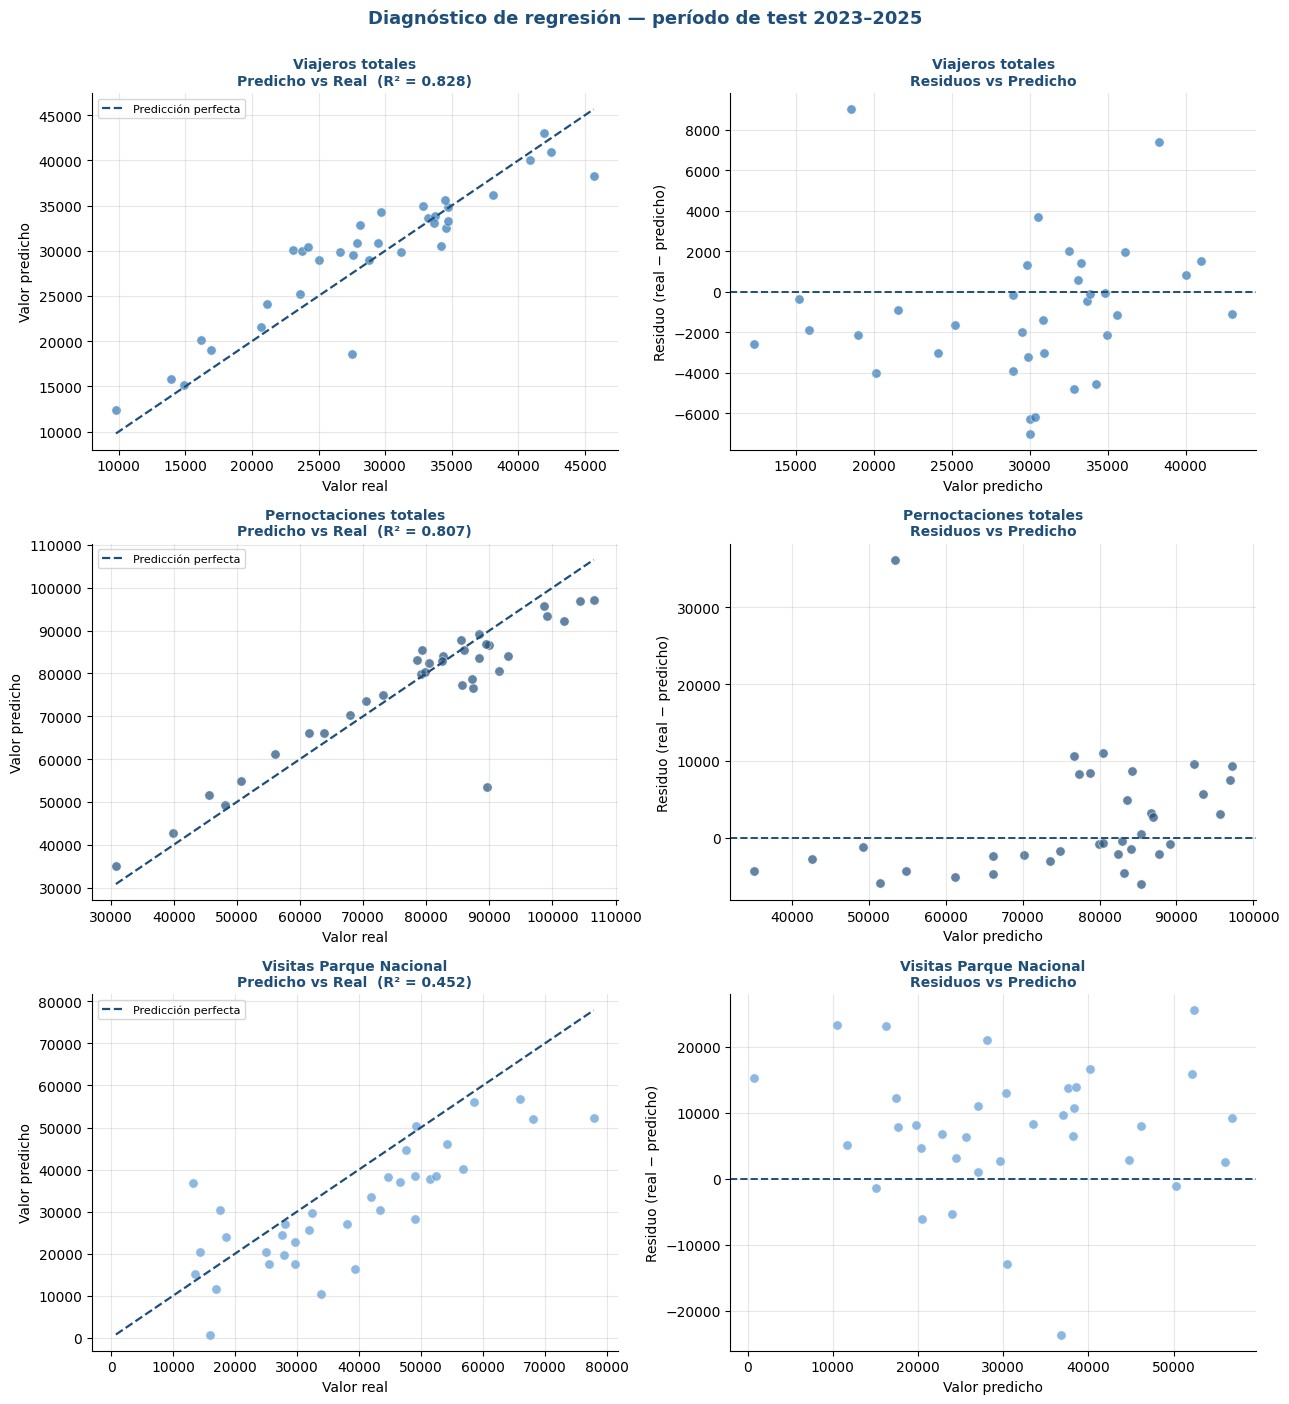

In [12]:
# ── Celda 8b: Diagnóstico de regresión — Predicho vs Real y Residuos vs Predicho ──

fig, axes = plt.subplots(3, 2, figsize=(13, 14))

for i, (label, color) in enumerate(COLOR_TARGET.items()):
    res      = resultados[label]
    y_test   = res['y_test']
    y_pred   = res['y_pred']
    residuos = y_test - y_pred

    # ── Columna 1: Predicho vs Real con diagonal de predicción perfecta ──
    ax1 = axes[i][0]
    ax1.scatter(y_test, y_pred, color=color, alpha=0.7, s=45,
                edgecolor='white', linewidth=0.5)
    lim_min = min(y_test.min(), y_pred.min())
    lim_max = max(y_test.max(), y_pred.max())
    ax1.plot([lim_min, lim_max], [lim_min, lim_max],
             color=AZUL_OSCURO, linestyle='--', linewidth=1.6,
             label='Predicción perfecta')
    ax1.set_xlabel('Valor real')
    ax1.set_ylabel('Valor predicho')
    ax1.set_title(f'{label}\nPredicho vs Real  (R² = {res["R2"]:.3f})', fontsize=10)
    ax1.legend(fontsize=8)

    # ── Columna 2: Residuos vs Predicho ──
    ax2 = axes[i][1]
    ax2.scatter(y_pred, residuos, color=color, alpha=0.7, s=45,
                edgecolor='white', linewidth=0.5)
    ax2.axhline(0, color=AZUL_OSCURO, linestyle='--', linewidth=1.4)
    ax2.set_xlabel('Valor predicho')
    ax2.set_ylabel('Residuo (real − predicho)')
    ax2.set_title(f'{label}\nResiduos vs Predicho', fontsize=10)

plt.suptitle('Diagnóstico de regresión — período de test 2023–2025',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Lectura del diagnóstico**

- **Predicho vs Real:** en viajeros y pernoctaciones los puntos se alinean estrechamente sobre la diagonal, confirmando el buen ajuste. En el Parque Nacional la nube está más dispersa, coherente con su menor R².
- **Residuos vs Predicho:** en los tres modelos los residuos se distribuyen alrededor de cero, pero su dispersión **crece levemente hacia la derecha** (valores predichos altos). Esto evidencia la **heterocedasticidad leve** ya anticipada en el análisis de outliers: el modelo es algo menos preciso en los meses de mayor demanda. Es el sustento visual de la recomendación de aplicar una transformación logarítmica del target.


## 8. Importancia de variables y residuos

### 8.1 Coeficientes del modelo

Como las variables están estandarizadas, los coeficientes son **comparables entre sí**: indican cuánto pesa cada predictor en cada modelo.


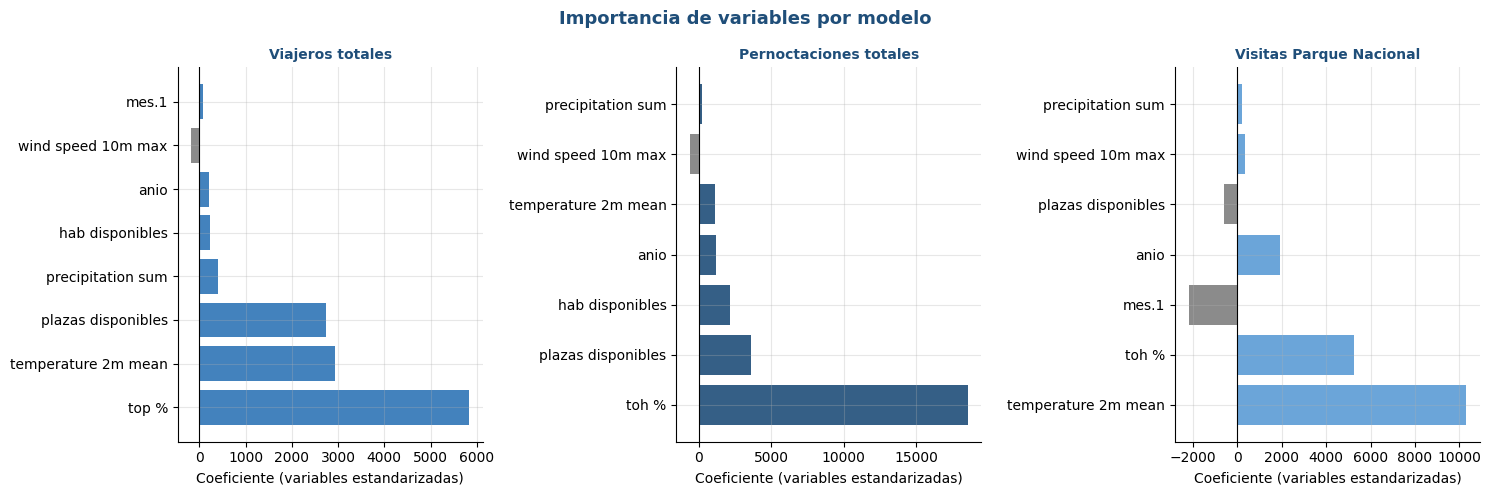

In [13]:
# ── Celda 9: Importancia de variables ──────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, color) in zip(axes, COLOR_TARGET.items()):
    coefs    = resultados[label]['modelo'].coef_
    features = resultados[label]['features']
    orden    = np.argsort(np.abs(coefs))[::-1]
    nombres_b = [f.replace('ush_', '').replace('_', ' ') for f in features]

    # Coef. positivos en el color del target; negativos en gris neutro
    colores_bar = [color if c > 0 else GRIS for c in coefs[orden]]

    ax.barh(
        [nombres_b[i] for i in orden],
        coefs[orden],
        color=colores_bar, alpha=0.9
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Coeficiente (variables estandarizadas)')

plt.suptitle('Importancia de variables por modelo',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura de coeficientes**

- **`ush_top %`** (ocupación de plazas): variable **dominante** en viajeros y pernoctaciones.
- **`ush_toh %`** (ocupación de habitaciones): es la que queda en el modelo del Parque (en viajeros y pernoctaciones fue descartada por su colinealidad con TOP%).
- **`temperature_2m_mean`**: peso alto en el Parque y relevante en viajeros — a mayor temperatura, más turistas (temporada de verano).
- **`mes.1`** captura la estacionalidad intra-anual; **`anio`** refleja la tendencia histórica de crecimiento.


### 8.2 Análisis de residuos en el tiempo

El residuo de cada mes es `real − predicho`. Un residuo positivo indica subestimación; uno negativo, sobreestimación.


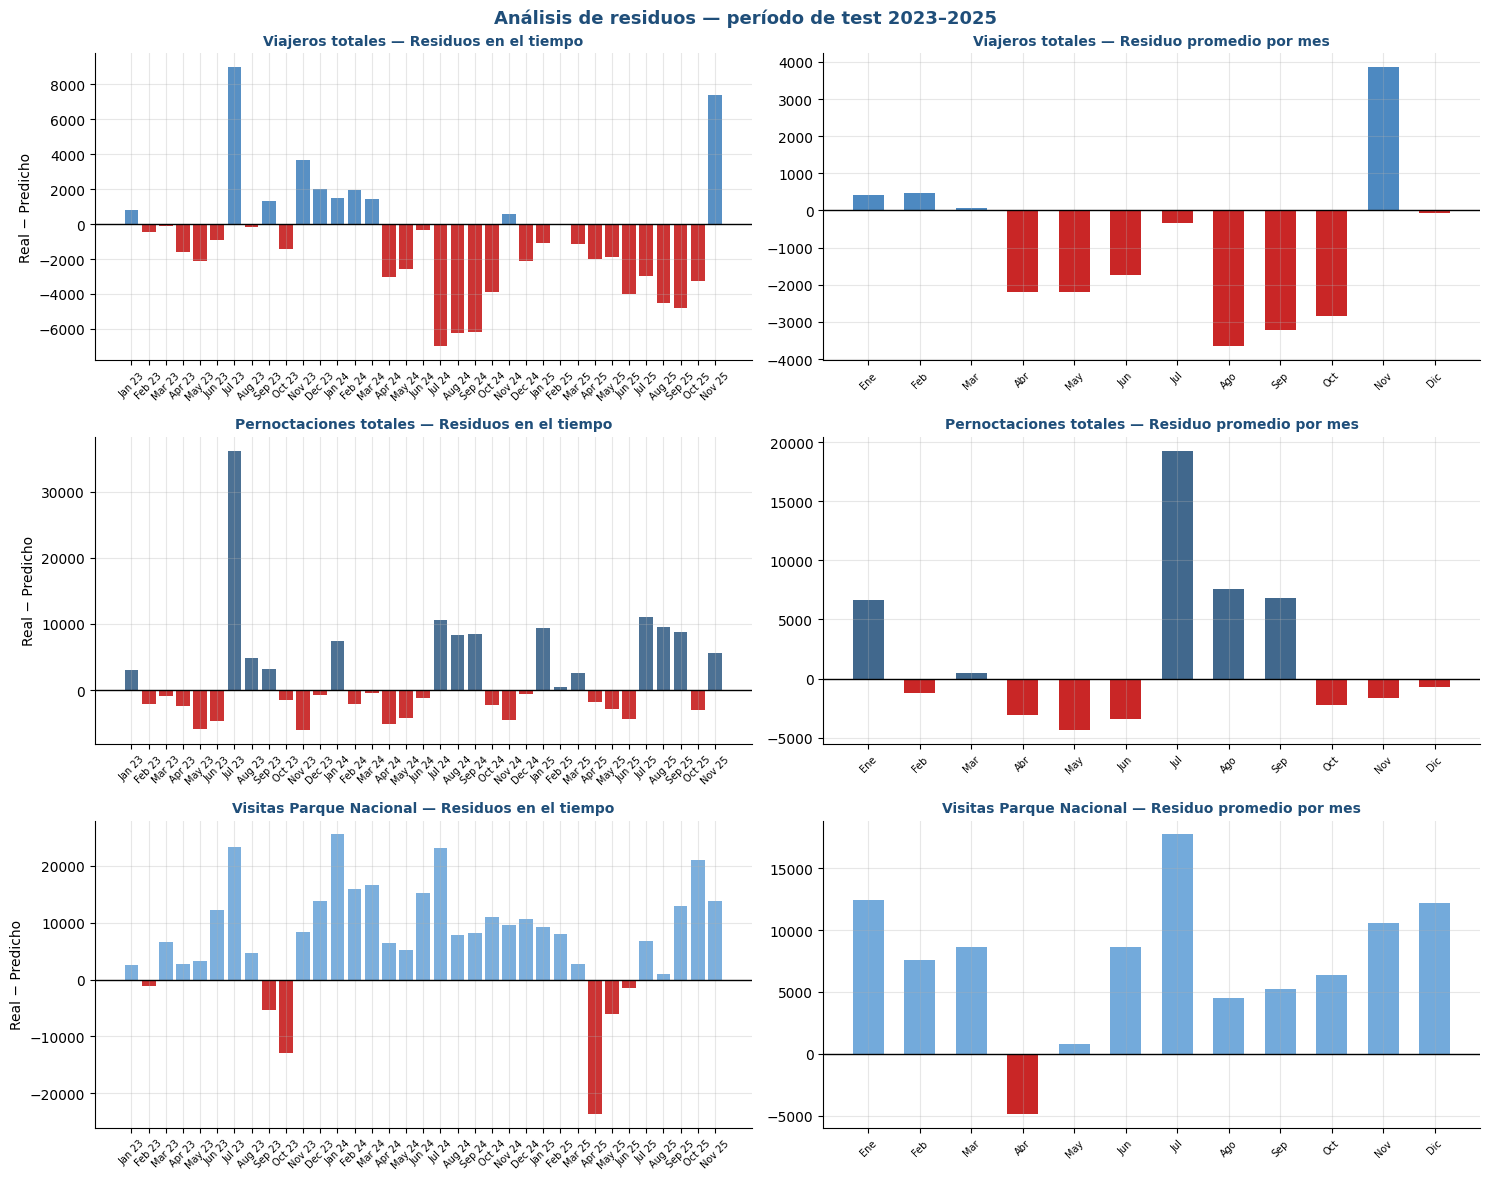

In [14]:
# ── Celda 10: Análisis de residuos (temporal y por mes) ────────────

meses_str = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for i, (label, color) in enumerate(COLOR_TARGET.items()):
    res      = resultados[label]
    residuos = res['y_test'] - res['y_pred']
    fechas   = res['fechas']
    meses    = res['meses']

    # ── Gráfico 1: Residuos en el tiempo
    ax1 = axes[i][0]
    colores_bar = [color if r >= 0 else ROJO_ALERTA for r in residuos]
    ax1.bar(range(len(fechas)), residuos, color=colores_bar, alpha=0.8)
    ax1.set_xticks(range(len(fechas)))
    ax1.set_xticklabels(
        [pd.Timestamp(f).strftime('%b %y') for f in fechas],
        rotation=45, fontsize=7)
    ax1.axhline(0, color='black', linewidth=1)
    ax1.set_title(f'{label} — Residuos en el tiempo', fontsize=10)
    ax1.set_ylabel('Real − Predicho')

    # ── Gráfico 2: Residuo promedio por mes
    ax2 = axes[i][1]
    df_res = pd.DataFrame({'mes': meses, 'residuo': residuos})
    res_mes = df_res.groupby('mes')['residuo'].mean()
    colores_mes = [color if v >= 0 else ROJO_ALERTA for v in res_mes.values]
    ax2.bar(res_mes.index, res_mes.values, color=colores_mes, alpha=0.85, width=0.6)
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_xticks(range(1, 13))
    ax2.set_xticklabels(meses_str, fontsize=7, rotation=45)
    ax2.set_title(f'{label} — Residuo promedio por mes', fontsize=10)

plt.suptitle('Análisis de residuos — período de test 2023–2025',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación del análisis de residuos**

- **Viajeros:** residuos pequeños y mayormente aleatorios, consistente con su R² = 0,828 (el mejor modelo).
- **Pernoctaciones:** subestima o sobreestima en algunos meses de temporada alta, con residuos algo mayores que en viajeros.
- **Parque Nacional:** residuos más dispersos, proporcionales a su menor R² = 0,452; los meses de otoño muestran sobreestimación sistemática.
- En los tres modelos hay **heterocedasticidad leve**: el error crece en los meses de mayor demanda, lo esperable en series turísticas con picos extremos.

## 9. Métricas y proyección

### 9.1 Resumen de métricas


In [15]:
# ── Celda 11: Resumen de métricas ──────────────────────────────────

datos_tabla = []

for label, res in resultados.items():
    datos_tabla.append({
        'Target':  label,
        'R²':      round(res['R2'],  3),
        'R² CV':   round(res['R2CV'],3),
        'MAE':     f"{res['MAE']:,.0f}",
        'RMSE':    f"{res['RMSE']:,.0f}",
    })

df_metricas = pd.DataFrame(datos_tabla).set_index('Target')
print(df_metricas.to_string())

                            R²  R² CV     MAE    RMSE
Target                                               
Viajeros totales         0.828  0.874   2,669   3,480
Pernoctaciones totales   0.807  0.903   5,337   8,114
Visitas Parque Nacional  0.452  0.241  10,239  12,308


**Interpretación de métricas**

| Target | R² (test) | R² CV | Interpretación |
|--------|-----------|-------|----------------|
| Viajeros totales | 0,828 | 0,874 | **Mejor modelo.** Explica el 83 % de la variación. Error promedio ≈ 2.700 viajeros/mes. |
| Pernoctaciones | 0,807 | 0,903 | Buen ajuste. Explica el 81 % de la variación. Error promedio ≈ 5.300 noches. |
| Parque Nacional | 0,452 | 0,241 | Modelo más débil. El bajo R² CV indica baja estabilidad entre folds, atribuible a los pocos datos disponibles (desde 2015). |

> **Nota:** el R² de test (0,828 / 0,807 / 0,452) es la métrica de referencia, ya que mide el desempeño sobre datos no vistos. El R² CV complementa indicando la estabilidad del modelo entre particiones del entrenamiento.

### 9.2 Proyección diciembre 2025 – noviembre 2026

Para construir las features futuras se utiliza la **mediana histórica de cada mes** (sin COVID) en las variables hoteleras y climáticas, actualizando únicamente `anio` y `mes.1`. Representa un **escenario base sin shocks externos**.


In [16]:
# ── Celda 12: Proyección diciembre 2025 – noviembre 2026 ────────────

meses_futuros = [
    (2025,12),(2026,1),(2026,2),(2026,3),
    (2026,4),(2026,5),(2026,6),(2026,7),
    (2026,8),(2026,9),(2026,10),(2026,11)
]
fechas_fut = pd.to_datetime([f'{a}-{m:02d}-01' for a,m in meses_futuros])
labels_fut = fechas_fut.strftime('%b %Y').tolist()

def features_futuros(anio, mes, features):
    """Construye la fila de predictores para un mes futuro usando la mediana
    histórica de ese mes; año y mes se fijan al período proyectado."""
    fila = df_modelo[df_modelo['mes.1'] == mes][features].median()
    if 'anio'  in fila.index: fila['anio']  = anio
    if 'mes.1' in fila.index: fila['mes.1'] = mes
    return fila.values.reshape(1, -1)

proj = pd.DataFrame({'Mes': labels_fut})

for label, res in resultados.items():
    features = res['features']
    preds = []
    for anio, mes in meses_futuros:
        X_fut = features_futuros(anio, mes, features)
        X_fut_scaled = res['scaler'].transform(X_fut)
        pred = res['modelo'].predict(X_fut_scaled)[0]
        preds.append(max(0, round(pred)))
    proj[label] = preds

proj = proj.set_index('Mes')
print(proj.to_string())

          Viajeros totales  Pernoctaciones totales  Visitas Parque Nacional
Mes                                                                        
Dec 2025             29850                   69811                    36803
Jan 2026             38498                   91738                    54915
Feb 2026             32095                   80104                    51164
Mar 2026             29517                   69149                    39968
Apr 2026             18401                   46464                    24711
May 2026             10237                   31522                    13338
Jun 2026              9258                   29335                     5098
Jul 2026             18767                   56043                    10252
Aug 2026             21541                   69271                    15184
Sep 2026             25932                   73717                    23209
Oct 2026             23725                   62079                    24400
Nov 2026    

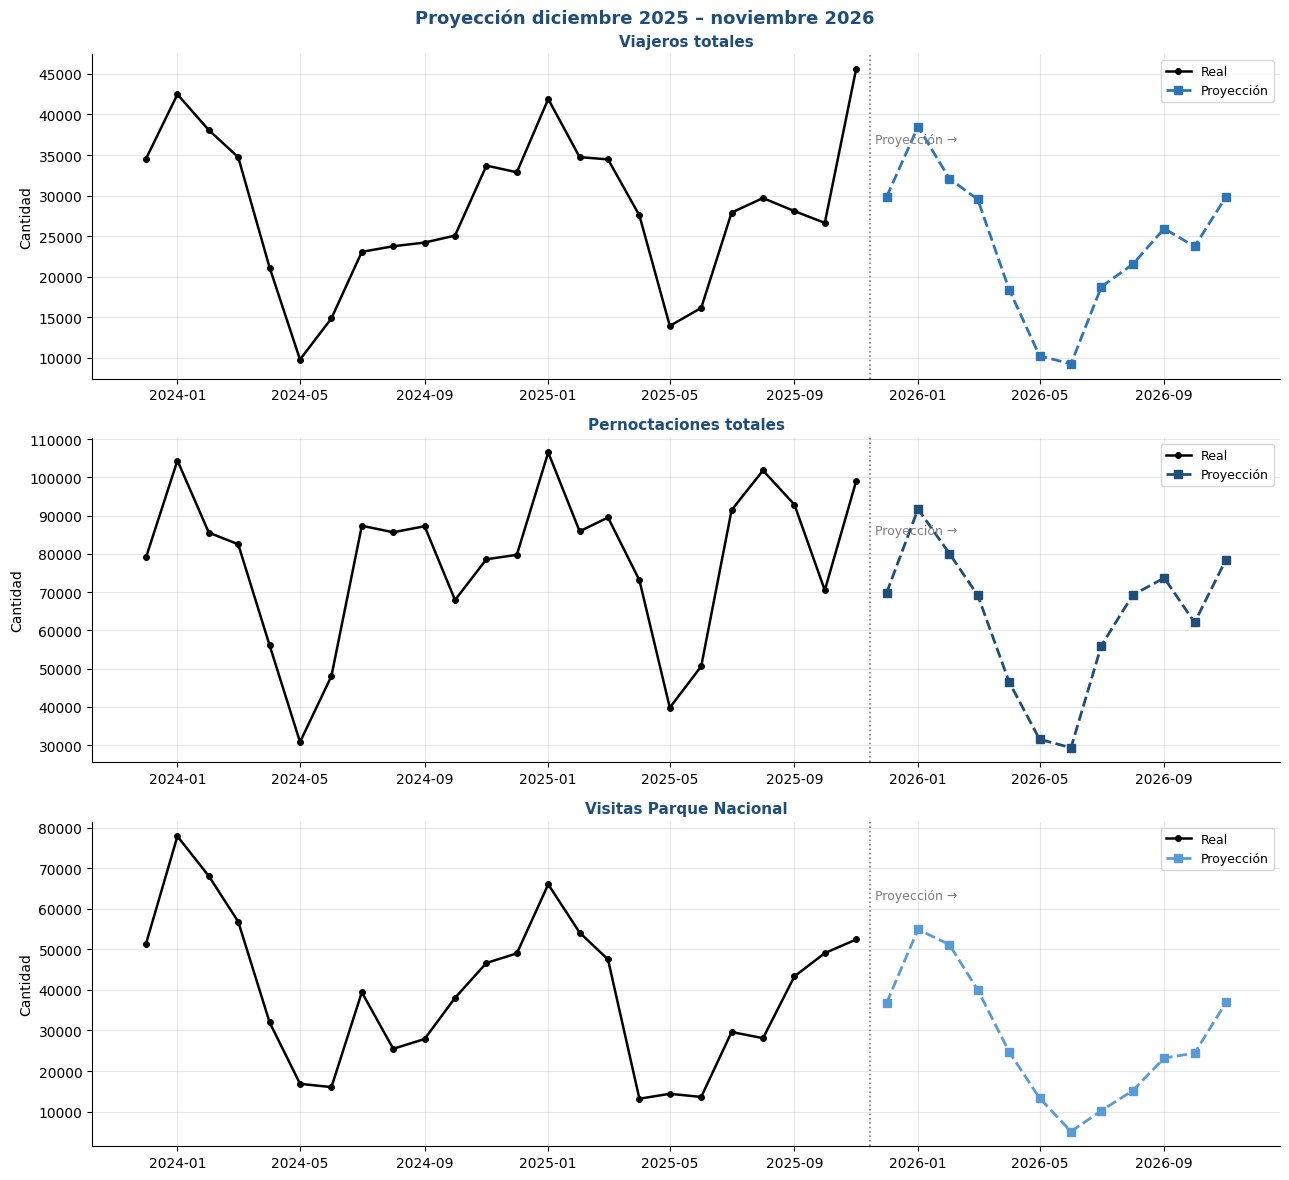

In [17]:
# ── Celda 13: Gráfico de proyección ────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

col_map = {
    'Viajeros totales':        'ush_viaj_total',
    'Pernoctaciones totales':  'ush_pernoc_total',
    'Visitas Parque Nacional': 'parque_visitas_total',
}

for ax, (label, color) in zip(axes, COLOR_TARGET.items()):
    col = col_map[label]
    hist = df_modelo.dropna(subset=[col]).tail(24)

    ax.plot(hist['fecha'], hist[col], 'o-', color='black',
            linewidth=1.8, markersize=4, label='Real')
    ax.plot(fechas_fut, proj[label].values, 's--', color=color,
            linewidth=2, markersize=6, label='Proyección')
    ax.axvline(pd.Timestamp('2025-11-15'), color=GRIS,
               linestyle=':', linewidth=1.2)
    ax.text(pd.Timestamp('2025-11-20'), hist[col].max()*0.8,
            'Proyección →', color=GRIS, fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Cantidad')
    ax.legend(fontsize=9)

plt.suptitle('Proyección diciembre 2025 – noviembre 2026',
             fontsize=13, color=AZUL_OSCURO, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Conclusiones y recomendaciones

### Modelo utilizado
Regresión Lineal Múltiple — **un modelo por cada variable objetivo**. Las features de cada modelo se seleccionaron por **Correlación + VIF**, por lo que no son idénticas entre targets.

### Resultados

| Target | R² (test) | Lectura |
|--------|:---------:|---------|
| Viajeros totales | **0,828** | El mejor modelo; explica el 83 % de la variación; error ≈ 2.700 viajeros/mes. |
| Pernoctaciones | **0,807** | Buen ajuste; explica el 81 % de la variación; error ≈ 5.300 noches/mes. |
| Visitas Parque Nacional | **0,452** | El más débil; baja estabilidad (R² CV 0,241) por contar con datos solo desde 2015. |

### Variables más importantes
- **Ocupación hotelera (TOP % / TOH %):** variable dominante en viajeros y pernoctaciones.
- **Temperatura media:** relación positiva, relevante en los tres modelos, especialmente en el Parque.
- **Precipitación:** se incorpora como predictor en los tres modelos.
- **Mes y año:** capturan estacionalidad y tendencia histórica.

### Hallazgos del EDA
- Ushuaia tiene **dos temporadas altas**: verano (ene–feb) e invierno (jul–ago).
- El Parque Nacional es un atractivo **principalmente de verano**.
- El turismo se **recuperó post-COVID** y superó los niveles previos a 2020.

### Diagnóstico de residuos
- Existe **heterocedasticidad leve** en los tres modelos: el error crece en los meses de mayor demanda, visible en el gráfico Residuos vs Predicho.

### Limitaciones
- El Parque Nacional tiene datos solo desde 2015 (pocos registros), reflejado en su bajo R² CV.
- La proyección usa **medianas históricas**, por lo que no captura shocks externos.
- El modelo asume **relaciones lineales** entre las variables.

### Recomendaciones para futuros trabajos
1. Aplicar una **transformación logarítmica** del target para atenuar la heterocedasticidad en los picos.
2. **Ampliar la base de datos** del Parque Nacional para mejorar su estabilidad.
3. Explorar **modelos no lineales** o específicos de series temporales (SARIMA, Prophet).
4. Incorporar **variables de shocks externos** (tipo de cambio, eventos) que el escenario base no contempla.

### Proyección 2026
- Picos esperados en **enero–febrero** (verano) y **julio–agosto** (nieve); valle más profundo en **mayo–junio**.
- Noviembre 2026: ≈ **29.843 viajeros** y ≈ **78.449 pernoctaciones**.

---

*Quién podría continuar este análisis:* organismos como el **IPIEC** o la **Secretaría de Turismo** podrían adoptar el modelo como herramienta de planificación y mantenerlo actualizado cada temporada.